In [ ]:
# Loading the MNIST dataset
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
# Standardizing
mean = train_images.mean()
std = train_images.std()
x_train = (train_images - mean) / std
x_test = (test_images - mean) / std

In [ ]:
# Designing the MLP model
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Flatten(input_shape=(28, 28))) # Input layer
model.add(layers.Dense(128, activation='relu')) # First hidden layer
model.add(layers.Dense(64, activation='relu')) # Second hidden layer
model.add(layers.Dense(10, activation='softmax')) # Output layer

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compiling the model with the properties asked
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the model
history = model.fit(train_images, train_labels, epochs=20, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7348 - loss: 4.9224 - val_accuracy: 0.8919 - val_loss: 0.4379
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9058 - loss: 0.3636 - val_accuracy: 0.9368 - val_loss: 0.2593
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9368 - loss: 0.2342 - val_accuracy: 0.9391 - val_loss: 0.2337
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9485 - loss: 0.1920 - val_accuracy: 0.9516 - val_loss: 0.1861
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9557 - loss: 0.1617 - val_accuracy: 0.9510 - val_loss: 0.1822
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9606 - loss: 0.1404 - val_accuracy: 0.9576 - val_loss: 0.1769
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9654 - loss: 0.1228 - val_accuracy: 0.9584 - val_loss: 0.1559
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9689 - loss: 0.1073

In [ ]:
# Evaluating the model
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9641 - loss: 0.2115
Test accuracy: 0.9684


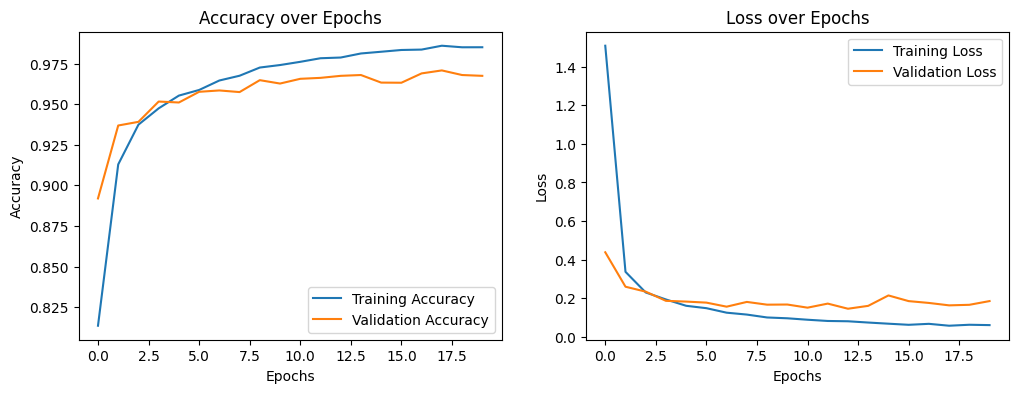

In [ ]:
# Plotting
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


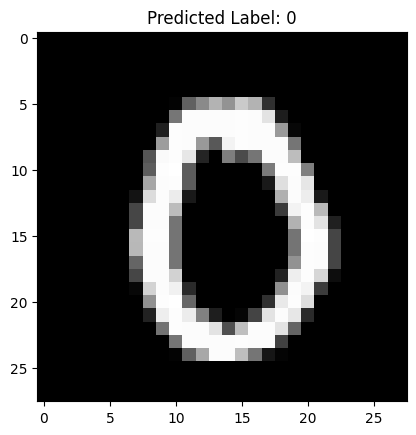

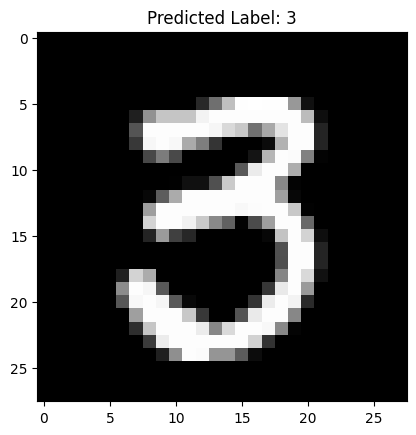

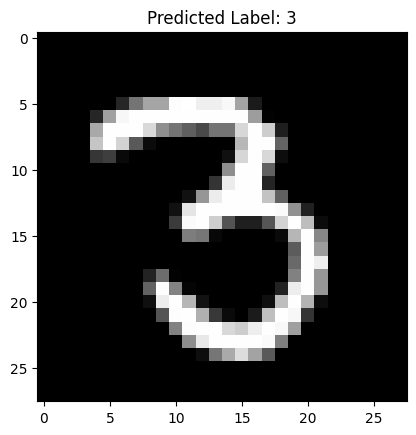

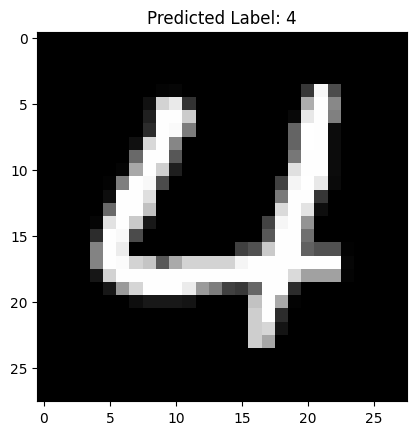

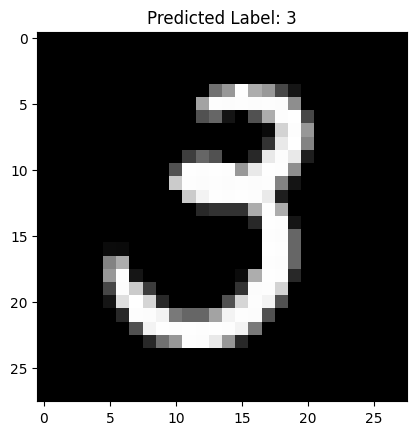

In [ ]:
# Testing
predictions = model.predict(test_images)

# Displaying 5 random test images along with predicted labels
import random
for _ in range(5):
    index = random.randint(0, test_images.shape[0] - 1)
    plt.imshow(test_images[index], cmap='gray')
    plt.title(f"Predicted Label: {np.argmax(predictions[index])}")
    plt.show()